<h3>SIG6-Chaîne de traitements de signal audio composite

In [1]:
from matplotlib.pyplot import axis, Circle, figure, GridSpec, minorticks_on, show, tight_layout, xlim
from numpy import abs, angle, imag, log10, pi, poly, real, size
from scipy.signal import freqz, sos2zpk, tf2zpk
import matplotlib

def zplane(G=[],TFname=[], whole=False, phase=True): #G prend plusieurs filtres en même temps
    indice = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']

    # Crée la grille de sous-graphiques
    fig = figure(figsize=(12, 8))
    gs  = GridSpec(2, 2, figure=fig)

    # Trace le cercle unité pour référence
    ax1 = fig.add_subplot(gs[:, 0])
    unit_circle = Circle((0, 0), 1, color='gray', fill=False, linestyle='dotted')
    ax1.add_artist(unit_circle)
    axis([-1.1, 1.1, -1.1, 1.1])
    ax1.set_title('Diagramme des Pôles et des Zéros')
    ax1.set_xlabel('Partie Réelle')
    ax1.set_ylabel('Partie Imaginaire')

    ax1.axhline(0, color='black', linewidth=0.5)
    ax1.axvline(0, color='black', linewidth=0.5)
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax1.set_aspect('equal', 'box')

    # Configure le tracé module de la réponse en fréquence
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_title('Module des réponses en fréquence')
    ax2.set_xlabel(r"$\nu$")
    ax2.set_ylabel('Amplitude')
    ax2.grid(True, which='major', linestyle='-', linewidth=0.5)
    minorticks_on()
    ax2.grid(True, which='minor', linestyle=':', linewidth=0.5)

    # Configure le tracé de la phase ou du module_dB de la réponse en fréquence
    ax3 = fig.add_subplot(gs[1, 1])
    if phase==True :
        ax3.set_title('Phase des réponses en fréquence')
        ax3.set_ylabel('Phase [°]')
    else:
        ax3.set_title('Module des réponses en fréquence')
        ax3.set_ylabel('Amplitude [dB]')
    ax3.set_xlabel(r"$\nu$")
    ax3.grid(True, which='major', linestyle='-', linewidth=0.5)
    minorticks_on()
    ax3.grid(True, which='minor', linestyle=':', linewidth=0.5)

    Z       = []
    P       = []
    K       = []
    H_amp   = []
    for i in range(len(G)):
        """Trace le diagramme des pôles et des zéros"""
        # Obtenir les pôles, zéros et gain du filtre
        
        zero, pole, gain = tf2zpk(G[i].num, G[i].den)
        nu, H = freqz(G[i].num, G[i].den, 1024, True, fs=1)

        Z.append(zero)
        P.append(pole)
        K.append(real(gain))
        H_amp.append(H)

        # Tracer les pôles et zéros
        ax1.scatter(real(zero), imag(zero), color='C' + f"{i+1}", facecolors='none', label='z' + indice[i])
        print(indice[i])
        print('zp :')
        print(Z)
        print('|zp| :')
        print(abs(Z))
        print('Arg(zp) :')
        print(angle(Z)) 
        ax1.scatter(real(pole), imag(pole), color='C' + f"{i+1}", marker='x', label='p' + indice[i])
        print('pq :')
        print(P)
        print('|pq| :')
        print(abs(P))
        print('Arg(pq) :')
        print(angle(P))
        ax1.legend()

        # Module de la réponse en fréquence
        ax2.plot(nu, abs(H)/max(abs(H)), color='C' + f"{i+1}", label=r"$\vert$" + TFname[i] + r"$(\nu)\vert$")
        if whole==False :
            ax2.set_xlim((0, 0.5))
        ax2.legend()

        # Phase ou module en dB de la réponse en fréquence
        if phase == True:
            ax3.plot(nu, angle(H) * 180 / pi, color='C' + f"{i + 1}", label="$arg[$" + TFname[i] + r"$(\nu)]$")
        else:
            ax3.plot(nu, 20 * log10(abs(H) + 2 ** (-16)), color='C' + f"{i + 1}",
                     label=r"$\vert$" + TFname[i] + r"$_{dB}(\nu)$" + r"$\vert$")
        if whole==False :
            xlim((0, 0.5))
        ax3.legend()

    tight_layout()
    show()
    return Z, P, K, H_amp,nu


V.1.1 Préparation : synthèse d'un filtre

In [2]:
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import scipy
import os
print(os.path.abspath(os.curdir)) #Bref si pas de sauvegarde de fichier/pas de répertoire courant !!
matplotlib.rcParams["text.usetex"] = False

C:\Users\nicol\Spyder_projects


In [3]:
#Perso-Tests
freq_Hz1a,RF_Hz1a=scipy.signal.freqz(Hz1a_n,Hz1a_d,whole='true')
freq_norm_Hz1a=[freq/freq_Hz1a[len(freq_Hz1a)-1] for freq in freq_Hz1a]
norm_RF_Hz1a=np.abs(RF_Hz1a)/max(np.abs(RF_Hz1a))
plt.plot(freq_norm_Hz1a,norm_RF_Hz1a,label='RF_Hz1a')

plt.xlabel('Fréquence normalisée')
plt.ylabel('Amplitude normalisée')

NameError: name 'Hz1a_n' is not defined

a
zp :
[array([-1. ,  0.6])]
|zp| :
[[1.  0.6]]
Arg(zp) :
[[3.14159265 0.        ]]
pq :
[array([0.65607176+0.6160924j, 0.65607176-0.6160924j])]
|pq| :
[[0.9 0.9]]
Arg(pq) :
[[ 0.75398224 -0.75398224]]
b
zp :
[array([-1. ,  0.6]), array([0.14579373+0.13690942j, 0.14579373-0.13690942j])]
|zp| :
[[1.  0.6]
 [0.2 0.2]]
Arg(zp) :
[[ 3.14159265  0.        ]
 [ 0.75398224 -0.75398224]]
pq :
[array([0.65607176+0.6160924j, 0.65607176-0.6160924j]), array([0.5831749+0.54763768j, 0.5831749-0.54763768j])]
|pq| :
[[0.9 0.9]
 [0.8 0.8]]
Arg(pq) :
[[ 0.75398224 -0.75398224]
 [ 0.75398224 -0.75398224]]
c
zp :
[array([-1. ,  0.6]), array([0.14579373+0.13690942j, 0.14579373-0.13690942j]), array([ 1. , -0.6])]
|zp| :
[[1.  0.6]
 [0.2 0.2]
 [1.  0.6]]
Arg(zp) :
[[ 3.14159265  0.        ]
 [ 0.75398224 -0.75398224]
 [ 0.          3.14159265]]
pq :
[array([0.65607176+0.6160924j, 0.65607176-0.6160924j]), array([0.5831749+0.54763768j, 0.5831749-0.54763768j]), array([0.38320136+0.81434435j, 0.38320136-0.814344

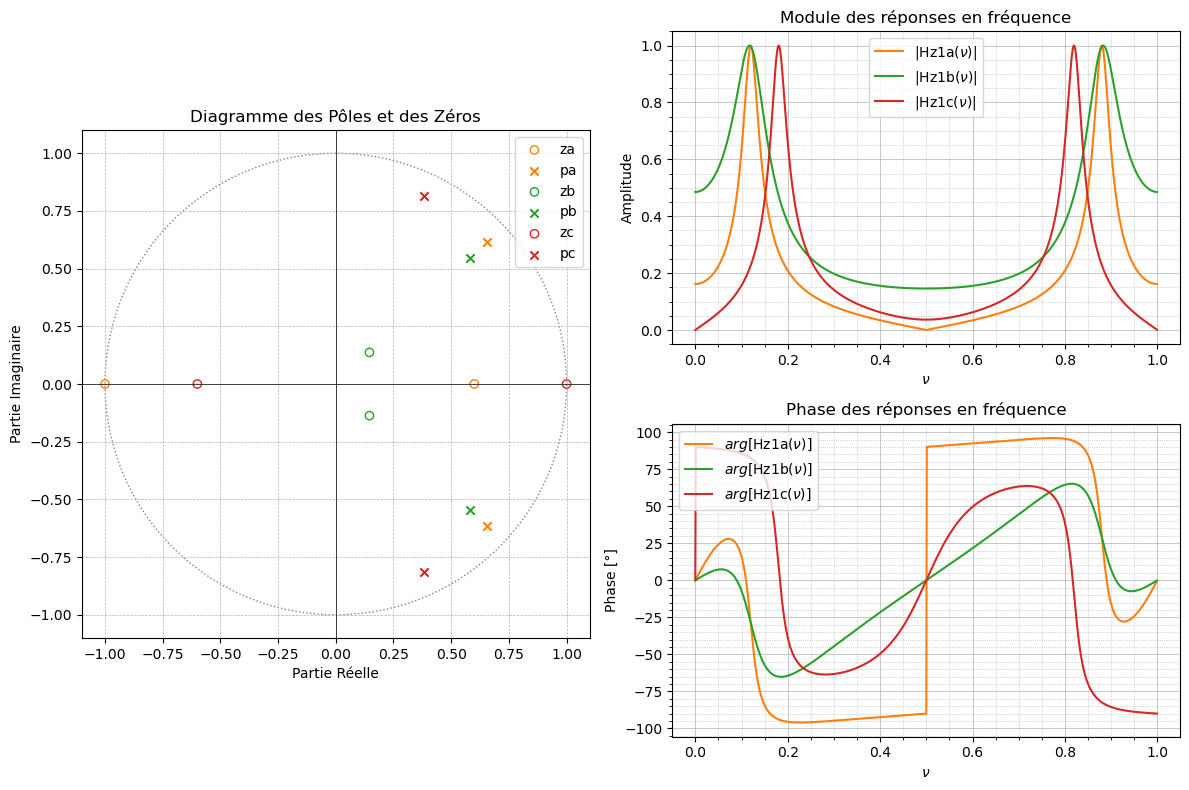

In [57]:
data_filtre = scipy.io.loadmat('placement.mat')
#print(data_filtre)

Hz1a_n=data_filtre['Hz1a_num'].flatten()
Hz1a_d=data_filtre['Hz1a_den'].flatten()
Hz1a=scipy.signal.TransferFunction(Hz1a_n,Hz1a_d)


Hz1b_n=data_filtre['Hz1b_num'].flatten()
Hz1b_d=data_filtre['Hz1b_den'].flatten()
Hz1b=scipy.signal.TransferFunction(Hz1b_n,Hz1b_d)


Hz1c_n=data_filtre['Hz1c_num'].flatten()
Hz1c_d=data_filtre['Hz1c_den'].flatten()
Hz1c=scipy.signal.TransferFunction(Hz1c_n,Hz1c_d)

L1=zplane([Hz1a,Hz1b,Hz1c],['Hz1a','Hz1b','Hz1c'],True,True)

a
zp :
[array([1.        +0.j        , 0.58778525+0.80901699j,
       0.58778525-0.80901699j])]
|zp| :
[[1. 1. 1.]]
Arg(zp) :
[[ 0.         0.9424778 -0.9424778]]
pq :
[array([-0.72811529+0.52900673j, -0.72811529-0.52900673j,
       -0.5       +0.j        ])]
|pq| :
[[0.9 0.9 0.5]]
Arg(pq) :
[[ 2.51327412 -2.51327412  3.14159265]]
b
zp :
[array([1.        +0.j        , 0.58778525+0.80901699j,
       0.58778525-0.80901699j]), array([1.        +0.j        , 0.58778525+0.80901699j,
       0.58778525-0.80901699j])]
|zp| :
[[1. 1. 1.]
 [1. 1. 1.]]
Arg(zp) :
[[ 0.         0.9424778 -0.9424778]
 [ 0.         0.9424778 -0.9424778]]
pq :
[array([-0.72811529+0.52900673j, -0.72811529-0.52900673j,
       -0.5       +0.j        ]), array([-0.6472136+0.4702282j, -0.6472136-0.4702282j,
       -0.4      +0.j       ])]
|pq| :
[[0.9 0.9 0.5]
 [0.8 0.8 0.4]]
Arg(pq) :
[[ 2.51327412 -2.51327412  3.14159265]
 [ 2.51327412 -2.51327412  3.14159265]]
c
zp :
[array([1.        +0.j        , 0.58778525+0.8090169

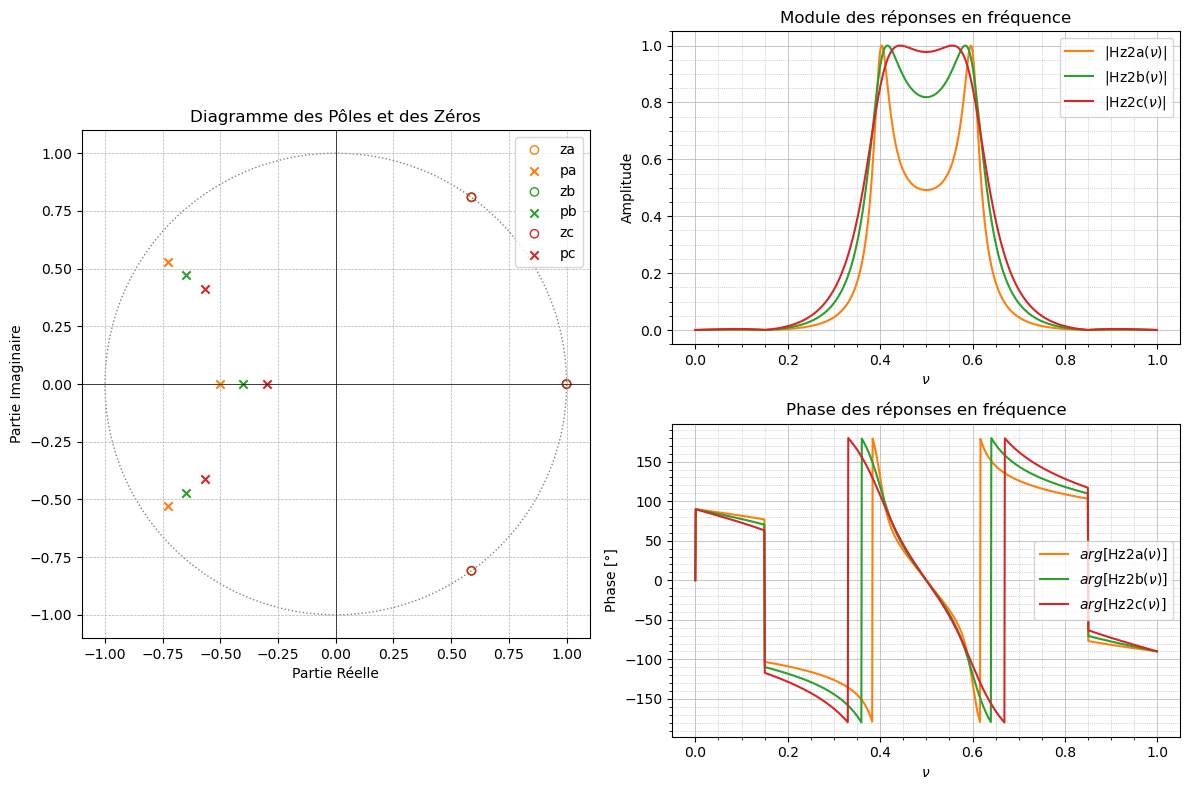

In [58]:
#Série n°2 des tracé
Hz2a_n=data_filtre['Hz2a_num'].flatten()
Hz2a_d=data_filtre['Hz2a_den'].flatten()
Hz2a=scipy.signal.TransferFunction(Hz2a_n,Hz2a_d)

Hz2b_n=data_filtre['Hz2b_num'].flatten()
Hz2b_d=data_filtre['Hz2b_den'].flatten()
Hz2b=scipy.signal.TransferFunction(Hz2b_n,Hz2b_d)

Hz2c_n=data_filtre['Hz2c_num'].flatten()
Hz2c_d=data_filtre['Hz2c_den'].flatten()
Hz2c=scipy.signal.TransferFunction(Hz2c_n,Hz2c_d)

L1=zplane([Hz2a,Hz2b,Hz2c],['Hz2a','Hz2b','Hz2c'],True,True)

VI.2. Séparation des sources

In [59]:
import soundfile
import sounddevice
audio, samplerate = soundfile.read('music.wav') #Goldeneye.wav
sounddevice.play(audio,samplerate)
sounddevice.wait()

44100


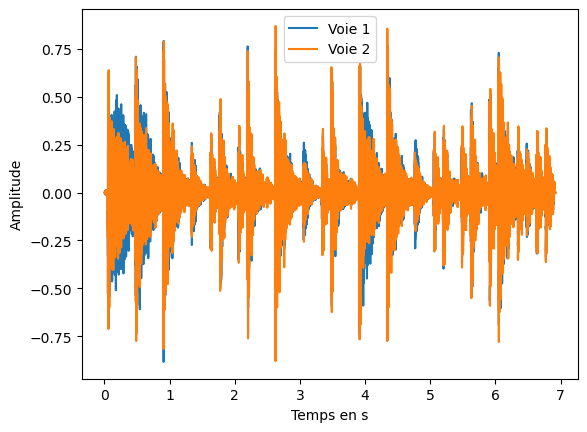

In [60]:
audio0=[audio[i][0] for i in range(len(audio))]
audio1=[audio[i][1] for i in range(len(audio))]
print(samplerate)
plt.plot(np.arange(len(audio0))/samplerate,audio0,label='Voie 1')
plt.plot(np.arange(len(audio1))/samplerate,audio1,label='Voie 2')
plt.xlabel('Temps en s')
plt.ylabel('Amplitude')
plt.legend()
plt.show()


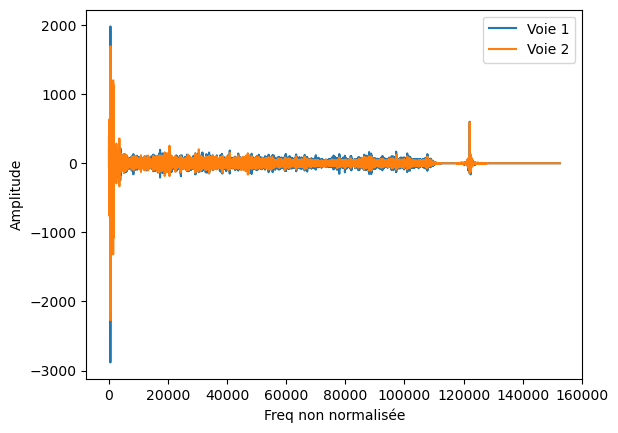

In [61]:
TFaudio0=np.fft.fft(audio0)
freqTFaudio=np.arange((int)(len(audio0)/2))
TFaudio1=np.fft.fft(audio1)
plt.plot(freqTFaudio,TFaudio0[:(int)(len(audio0)/2)],label='Voie 1')
plt.plot(freqTFaudio,TFaudio1[:(int)(len(audio0)/2)],label='Voie 2')
plt.xlabel('Freq non normalisée')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

44100


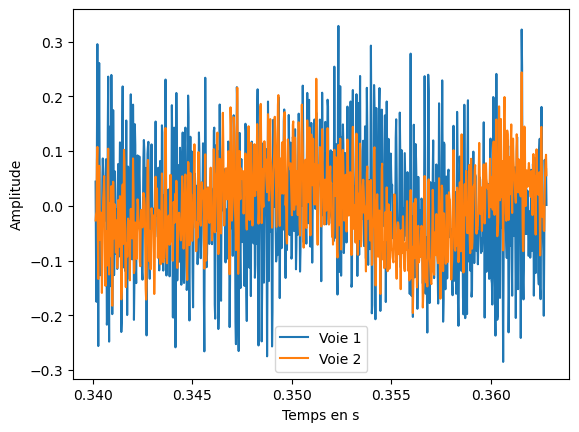

In [62]:
audio0=[audio[i][0] for i in range(len(audio))]
audio1=[audio[i][1] for i in range(len(audio))]
print(samplerate)
plt.plot(np.arange(len(audio0))[15000:16000]/samplerate,audio0[15000:16000],label='Voie 1')
plt.plot(np.arange(len(audio1))[15000:16000]/samplerate,audio1[15000:16000],label='Voie 2')
plt.xlabel('Temps en s')
plt.ylabel('Amplitude')
plt.legend()
plt.show()
#♠Echelle 0.02s

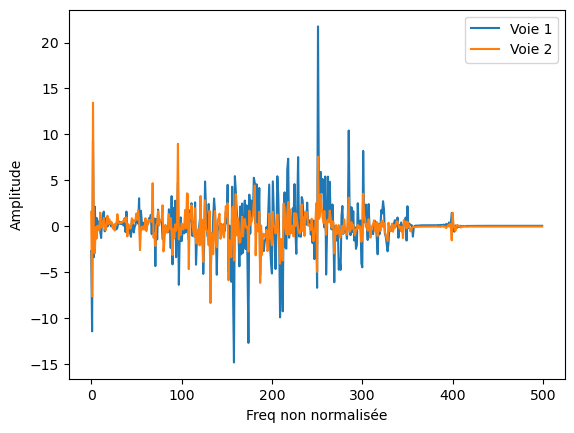

In [63]:
TFaudio0=np.fft.fft(audio0[15000:16000])
freqTFaudio=np.arange((int)(len(audio0[15000:16000])/2))
TFaudio1=np.fft.fft(audio1[15000:16000])
plt.plot(freqTFaudio,TFaudio0[:(int)(len(audio0[15000:16000])/2)],label='Voie 1')
plt.plot(freqTFaudio,TFaudio1[:(int)(len(audio0[15000:16000])/2)],label='Voie 2')
plt.xlabel('Freq non normalisée')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

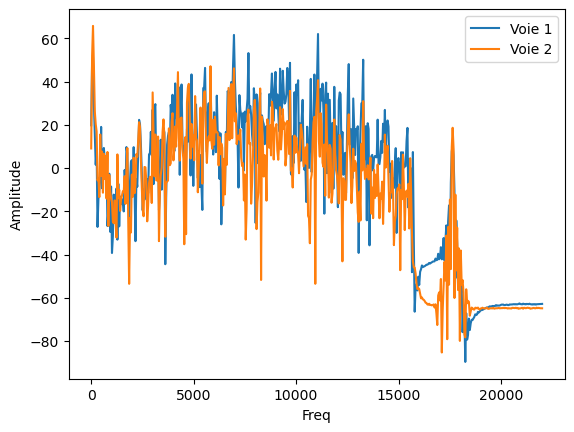

In [64]:
TFaudio0=np.fft.fft(audio0[15000:16000])
freqTFaudio=np.arange((int)(len(audio0[15000:16000])/2))
TFaudio1=np.fft.fft(audio1[15000:16000])
plt.plot(freqTFaudio*samplerate/2/len(freqTFaudio),20*np.log(TFaudio0[:(int)(len(audio0[15000:16000])/2)]),label='Voie 1')
plt.plot(freqTFaudio*samplerate/2/len(freqTFaudio),20*np.log(TFaudio1[:(int)(len(audio0[15000:16000])/2)]),label='Voie 2')
#A demander
plt.xlabel('Freq')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

Les 2 bandes utiles sont [0,15000] et [♥15000,17000] (échelle bonne ?)

On veut un filtre passe bas de coupure 15000 et un filtre passe haut de coupure 15000. Gain unitaire de préférence.

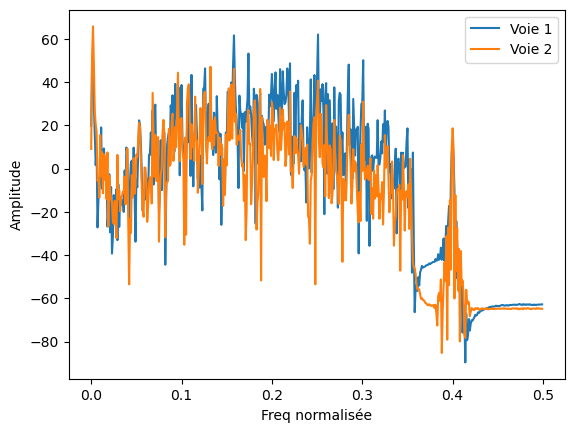

In [65]:
TFaudio0=np.fft.fft(audio0[15000:16000])
freqTFaudio=np.arange((int)(len(audio0[15000:16000])/2))
TFaudio1=np.fft.fft(audio1[15000:16000])
plt.plot(freqTFaudio/2/len(freqTFaudio),20*np.log(TFaudio0[:(int)(len(audio0[15000:16000])/2)]),label='Voie 1')
plt.plot(freqTFaudio/2/len(freqTFaudio),20*np.log(TFaudio1[:(int)(len(audio0[15000:16000])/2)]),label='Voie 2')
plt.xlabel('Freq normalisée')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

Pour être plus précis, on veut un filtre tel que passe bas jusqu'à 0.35 et un autre passe haut à 0.36.

On va se baser sur les filtres faits à la préparation : la première série de filtre peut servir de passe-bas, on va prendre le Hz1b car on veut juste réduire l'influence du pic de la voie 2.

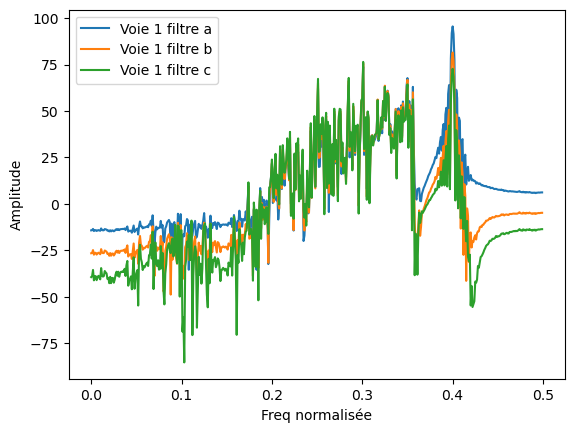

In [83]:
audio0fa=scipy.signal.lfilter(Hz2a.num,Hz2a.den,audio0[15000:16000])
TFaudio0fa=np.fft.fft(audio0fa)
freqTFaudio=np.arange((int)(len(audio0fa)/2))

audio0fb=scipy.signal.lfilter(Hz2b.num,Hz2b.den,audio0[15000:16000])
TFaudio0fb=np.fft.fft(audio0fb)
freqTFaudio=np.arange((int)(len(audio0fb)/2))

audio0fc=scipy.signal.lfilter(Hz2c.num,Hz2c.den,audio0[15000:16000])
TFaudio0fc=np.fft.fft(audio0fc)
freqTFaudio=np.arange((int)(len(audio0fc)/2))

plt.plot((freqTFaudio/2/len(freqTFaudio)),20*np.log(TFaudio0fa[:(int)(len(audio0fa)/2)]),label='Voie 1 filtre a')
plt.plot((freqTFaudio/2/len(freqTFaudio)),20*np.log(TFaudio0fb[:(int)(len(audio0fa)/2)]),label='Voie 1 filtre b')
plt.plot((freqTFaudio/2/len(freqTFaudio)),20*np.log(TFaudio0fc[:(int)(len(audio0fa)/2)]),label='Voie 1 filtre c')

TFaudio1=np.fft.fft(audio1[15000:16000])
#plt.plot((freqTFaudio/2/len(freqTFaudio))[300:],scipy.signal.lfilter(Hz1a.num,Hz1a.den,20*np.log(TFaudio0[:(int)(len(audio0[15000:16000])/2)]))[300:],label='Voie 1 filtré')

#plt.plot(freqTFaudio/2/len(freqTFaudio),20*np.log(TFaudio1[:(int)(len(audio0[15000:16000])/2)]),label='Voie 2')
plt.xlabel('Freq normalisée')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

In [101]:
Hz2F=scipy.signal.zpk2tf([1 , 0.59+0.81j , 0.59-0.81j],[-0.78+0.58j , -0.78-0.58j , -0.55],1)
Hz2F=scipy.signal.TransferFunction(Hz2F[0],Hz2F[1])

a
zp :
[array([1.  +0.j  , 0.59+0.81j, 0.59-0.81j])]
|zp| :
[[1.        1.0020978 1.0020978]]
Arg(zp) :
[[ 0.          0.94126636 -0.94126636]]
pq :
[array([-0.78+0.58j, -0.78-0.58j, -0.55+0.j  ])]
|pq| :
[[0.97200823 0.97200823 0.55      ]]
Arg(pq) :
[[ 2.50220675 -2.50220675  3.14159265]]


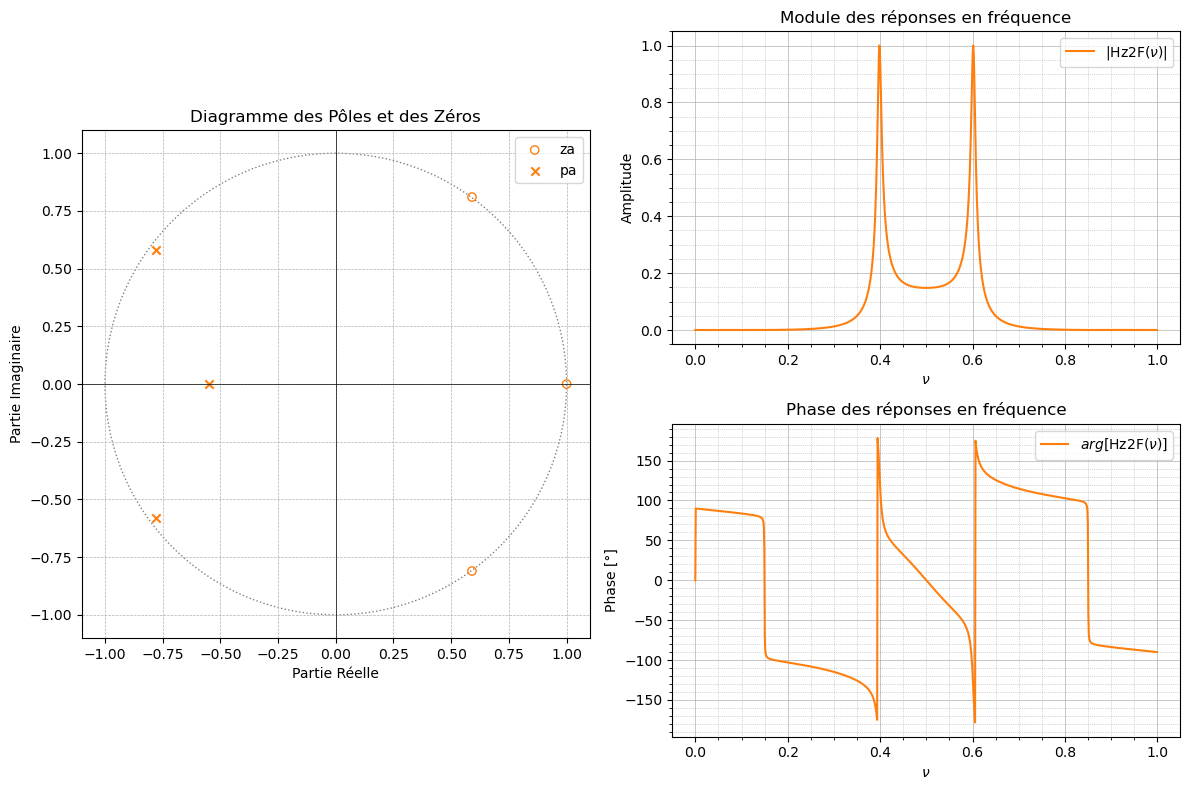

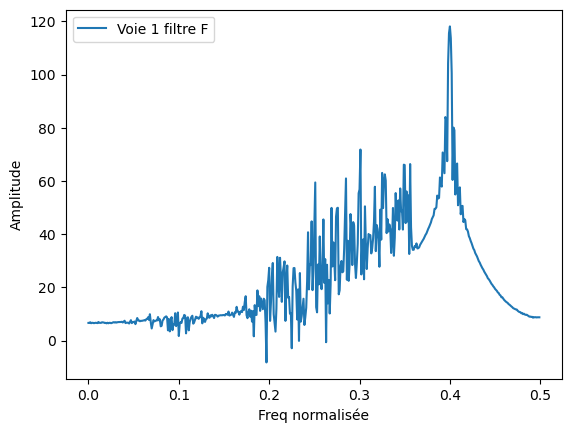

In [103]:
audio0fc=scipy.signal.lfilter(Hz2F.num,Hz2F.den,audio0[15000:16000])
TFaudio0fc=np.fft.fft(audio0fc)
freqTFaudio=np.arange((int)(len(audio0fc)/2))

plt.plot((freqTFaudio/2/len(freqTFaudio)),20*np.log(TFaudio0fc[:(int)(len(audio0fa)/2)]),label='Voie 1 filtre F')

TFaudio1=np.fft.fft(audio1[15000:16000])
#plt.plot((freqTFaudio/2/len(freqTFaudio))[300:],scipy.signal.lfilter(Hz1a.num,Hz1a.den,20*np.log(TFaudio0[:(int)(len(audio0[15000:16000])/2)]))[300:],label='Voie 1 filtré')

#plt.plot(freqTFaudio/2/len(freqTFaudio),20*np.log(TFaudio1[:(int)(len(audio0[15000:16000])/2)]),label='Voie 2')
plt.xlabel('Freq normalisée')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

a
zp :
[array([0.14579373+0.13690942j, 0.14579373-0.13690942j])]
|zp| :
[[0.2 0.2]]
Arg(zp) :
[[ 0.75398224 -0.75398224]]
pq :
[array([0.5831749+0.54763768j, 0.5831749-0.54763768j])]
|pq| :
[[0.8 0.8]]
Arg(pq) :
[[ 0.75398224 -0.75398224]]
b
zp :
[array([0.14579373+0.13690942j, 0.14579373-0.13690942j]), array([0.15+0.14j, 0.15-0.14j])]
|zp| :
[[0.2        0.2       ]
 [0.20518285 0.20518285]]
Arg(zp) :
[[ 0.75398224 -0.75398224]
 [ 0.75092906 -0.75092906]]
pq :
[array([0.5831749+0.54763768j, 0.5831749-0.54763768j]), array([0.66+0.62j, 0.66-0.62j])]
|pq| :
[[0.8        0.8       ]
 [0.90553851 0.90553851]]
Arg(pq) :
[[ 0.75398224 -0.75398224]
 [ 0.75415833 -0.75415833]]
c
zp :
[array([0.14579373+0.13690942j, 0.14579373-0.13690942j]), array([0.15+0.14j, 0.15-0.14j]), array([0.15+0.14j, 0.15-0.14j])]
|zp| :
[[0.2        0.2       ]
 [0.20518285 0.20518285]
 [0.20518285 0.20518285]]
Arg(zp) :
[[ 0.75398224 -0.75398224]
 [ 0.75092906 -0.75092906]
 [ 0.75092906 -0.75092906]]
pq :
[array([0.5

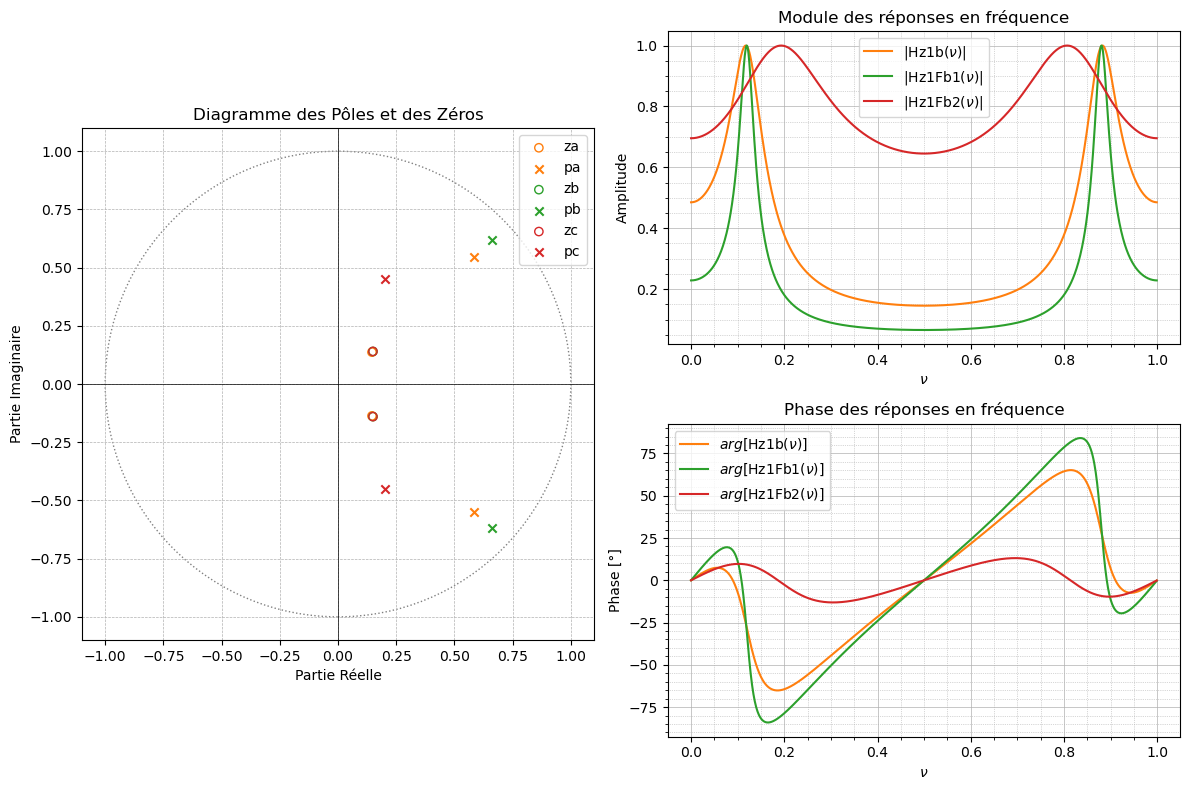

In [118]:
Hz1Fb1=scipy.signal.zpk2tf([0.15+0.14j , 0.15-0.14j],[0.66+0.62j,0.66-0.62j],1)
Hz1Fb1=scipy.signal.TransferFunction(Hz1Fb1[0],Hz1Fb1[1])
Hz1Fb2=scipy.signal.zpk2tf([0.15+0.14j , 0.15-0.14j],[0.20+0.45j , 0.20-0.45j],1)
Hz1Fb2=scipy.signal.TransferFunction(Hz1Fb2[0],Hz1Fb2[1])
L1=zplane([Hz1b,Hz1Fb1,Hz1Fb2],['Hz1b','Hz1Fb1','Hz1Fb2'],True,True)

a
zp :
[array([-1. ,  0.6])]
|zp| :
[[1.  0.6]]
Arg(zp) :
[[3.14159265 0.        ]]
pq :
[array([0.65607176+0.6160924j, 0.65607176-0.6160924j])]
|pq| :
[[0.9 0.9]]
Arg(pq) :
[[ 0.75398224 -0.75398224]]
b
zp :
[array([-1. ,  0.6]), array([-1. ,  0.6])]
|zp| :
[[1.  0.6]
 [1.  0.6]]
Arg(zp) :
[[3.14159265 0.        ]
 [3.14159265 0.        ]]
pq :
[array([0.65607176+0.6160924j, 0.65607176-0.6160924j]), array([0.06+0.9j, 0.06-0.9j])]
|pq| :
[[0.9        0.9       ]
 [0.90199778 0.90199778]]
Arg(pq) :
[[ 0.75398224 -0.75398224]
 [ 1.50422816 -1.50422816]]
c
zp :
[array([-1. ,  0.6]), array([-1. ,  0.6]), array([-1. ,  0.6])]
|zp| :
[[1.  0.6]
 [1.  0.6]
 [1.  0.6]]
Arg(zp) :
[[3.14159265 0.        ]
 [3.14159265 0.        ]
 [3.14159265 0.        ]]
pq :
[array([0.65607176+0.6160924j, 0.65607176-0.6160924j]), array([0.06+0.9j, 0.06-0.9j]), array([0.15+0.3j, 0.15-0.3j])]
|pq| :
[[0.9        0.9       ]
 [0.90199778 0.90199778]
 [0.3354102  0.3354102 ]]
Arg(pq) :
[[ 0.75398224 -0.75398224]
 

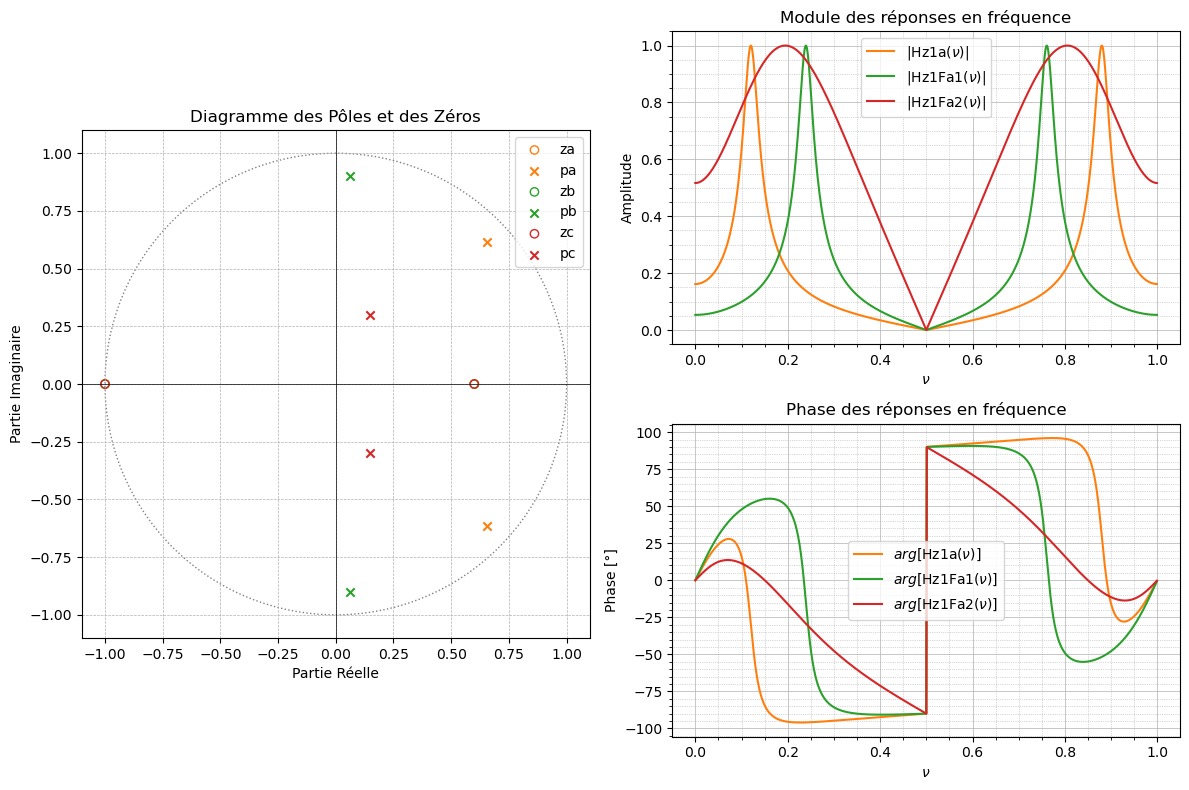

In [139]:
Hz1Fa1=scipy.signal.zpk2tf([-1 , 0.6],[0.06+0.9j ,0.06-0.9j],1)
Hz1Fa1=scipy.signal.TransferFunction(Hz1Fa1[0],Hz1Fa1[1])
Hz1Fa2=scipy.signal.zpk2tf([-1 , 0.6],[0.15+0.3j,0.15-0.3j],1)
Hz1Fa2=scipy.signal.TransferFunction(Hz1Fa2[0],Hz1Fa2[1])
L1=zplane([Hz1a,Hz1Fa1,Hz1Fa2],['Hz1a','Hz1Fa1','Hz1Fa2'],True,True)